# Day-Ahead Hourly Load Forecasting for SE/CO — A Comparative Study

**The question:** *How well can we forecast hourly electricity load one day ahead for Brazil's Southeast/Center-West subsystem — and which model wins, once we judge them not only by statistical error but by what the error costs in dispatch?*

This notebook is the narrated core of the comparative study. It walks through the data, the cleaning decisions, the exploratory findings, and a fair model comparison — from a seasonal-naïve baseline up to a zero-shot time-series foundation model (Chronos-2), with classical models (SARIMA, Prophet) in between.

**What you will learn**
- What the ONS load series looks like, and the three structural breaks hidden in it.
- Why the evaluation is **temporal, never shuffled**, and how day-ahead validation is set up.
- How the four models compare on **MASE, MAPE, and a dispatch-cost proxy**.
- Two findings that go beyond "the big model wins": (a) the ranking by statistical error is **not** the ranking by cost; (b) forecast temperature helps most in the **expensive** hours.

> **How to run.** This notebook *reads saved predictions* from `data/processed/` rather than retraining (Prophet alone takes ~3 h). It restarts-and-runs top-to-bottom in seconds. To regenerate the predictions from scratch, see `python run_all.py --stage models` and `docs/SETUP.md`. Data provenance and the full data dictionary are in `docs/DATA_CARD.md`.

*All headline numbers are cross-checked against `reports/FACTS.md`, the project's canonical facts sheet.*


## 1. Setup & imports

**Contents:** (1) setup · (2) data & first look · (3) cleaning, with the *why* · (4) EDA — seasonality, breaks, temperature · (5) the comparative study · (6) findings · (7) conclusion.

Minimal, pinned environment (see `requirements.txt`). We fix a seed for any stochastic step and set a consistent chart style up front so every figure below is styled beyond matplotlib defaults.

In [1]:
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

SEED = 42
np.random.seed(SEED)

# consistent, non-default styling for every chart in this notebook
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
})

# one color per model, used consistently throughout
COR = {"naive": "#8c8c8c", "SARIMA": "#3b6cb7", "Prophet": "#e08a3c", "Chronos-2": "#3fa85f"}

PROC = Path("../data/processed")   # relative path — notebook lives in notebooks/
SRC = Path("../src")                # reuse the project's own metric functions, not reimplement them
assert PROC.exists(), f"not found: {PROC.resolve()}"
assert SRC.exists(), f"not found: {SRC.resolve()}"
sys.path.insert(0, str(SRC.resolve()))


## 2. Data loading & first look

The target is **hourly load for the SE/CO subsystem**, in MWmed (average MW over the hour), published by ONS. We load the cleaned series and take a first look at its shape, dtypes, and datetime index before doing anything else.

In [2]:
carga = pd.read_parquet(PROC / "carga_se.parquet")
print("shape:", carga.shape)
print("range:", carga["din_instante"].min(), "→", carga["din_instante"].max())
carga.dtypes

shape: (101136, 3)
range: 2015-01-01 00:00:00 → 2026-07-15 23:00:00


din_instante               datetime64[ns]
val_cargaenergiahomwmed           float64
is_dst_transition                    bool
dtype: object

In [3]:
# the datetime index is local time (America/Sao_Paulo), hourly, not shuffled
carga = carga.sort_values("din_instante").reset_index(drop=True)
carga.head(3)

,din_instante,val_cargaenergiahomwmed,is_dst_transition
0,2015-01-01 00:00:00,31919.325,False
1,2015-01-01 01:00:00,31728.896,False
2,2015-01-01 02:00:00,31222.719,False


**What this is:** ~101k hourly rows from 2015 to mid-2026, one subsystem, a single continuous local-time grid. No shuffling — order is the signal.

## 3. Cleaning — and *why* each step

The raw ONS data has quirks that matter for forecasting. Each step below is preceded by the reason, not just the code.

**Why coerce the target to float:** ONS stores `val_cargaenergiahomwmed` as *text* in 2015–2024 and as float in 2025–2026 (a documented dictionary divergence). A naïve load would mix types. We coerce and keep NaNs as NaNs.

In [4]:
carga["carga"] = pd.to_numeric(carga["val_cargaenergiahomwmed"], errors="coerce")
n_nan = carga["carga"].isna().sum()
print(f"NaN load values (kept, not imputed): {n_nan}")   # expected 28 for SE

NaN load values (kept, not imputed): 28


**Why not impute the gaps:** the missing hours are (a) one full day in 2015 and (b) four daylight-saving-transition hours in October that, in local time, *did not occur*. Imputing would invent load for a nonexistent hour. We leave them NaN and exclude the 9 DST-transition timestamps as forecast origins.

In [5]:
# DST-transition flag already carried in the feature file; shown here for transparency
feat = pd.read_parquet(PROC / "features_se.parquet")
print("feature columns:", list(feat.columns))
print("DST-transition rows flagged:", int(feat["is_dst_transition"].sum()))   # expected 9

feature columns: ['din_instante', 'hora', 'dia_semana', 'mes', 'dia_ano', 'is_fim_de_semana', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_ano_sin', 'dia_ano_cos', 'dst_ativo', 'is_dst_transition', 'is_feriado', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_336h', 'media_24h', 'media_168h', 'media_mesma_hora_7d']
DST-transition rows flagged: 9


**Why these features:** load is driven by clock-anchored human behavior, so calendar features (hour, day-of-week, month, holiday) carry most of the signal. Lags are all ≥ 24 h because a day-ahead forecast at midnight of day D can only use data up to the end of D−1. **This is the leakage guard** — no feature may peek past the forecast origin.

## 4. Exploratory analysis

Each chart below opens with the question it answers and closes with the takeaway.

**Q: What does the daily load shape look like, and does it move across the year?**
We plot the average hourly profile by month — this exposes daily *and* annual seasonality at once.

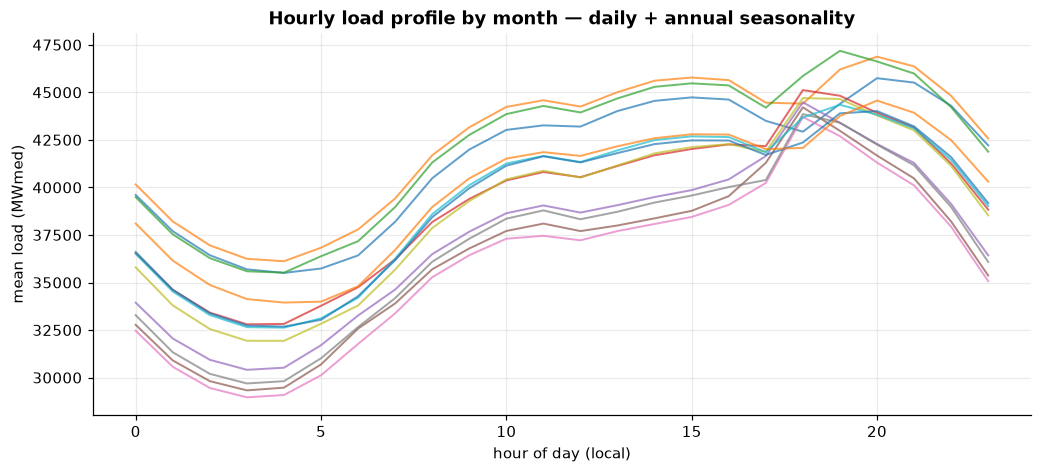

In [6]:
carga["hora"] = carga["din_instante"].dt.hour
carga["mes"] = carga["din_instante"].dt.month
perfil = carga.pivot_table(index="hora", columns="mes", values="carga", aggfunc="mean")

fig, ax = plt.subplots()
for m in perfil.columns:
    ax.plot(perfil.index, perfil[m], alpha=0.7, lw=1.3)
ax.set_xlabel("hour of day (local)"); ax.set_ylabel("mean load (MWmed)")
ax.set_title("Hourly load profile by month — daily + annual seasonality")
plt.show()

**Takeaway:** a clear twice-daily shape (afternoon and evening peaks) that shifts in level and timing across months — the seasonality a good model must capture.

**Q: Are there structural breaks that make some periods unlike others?**
We plot the full series (daily mean) with the three known breaks marked.

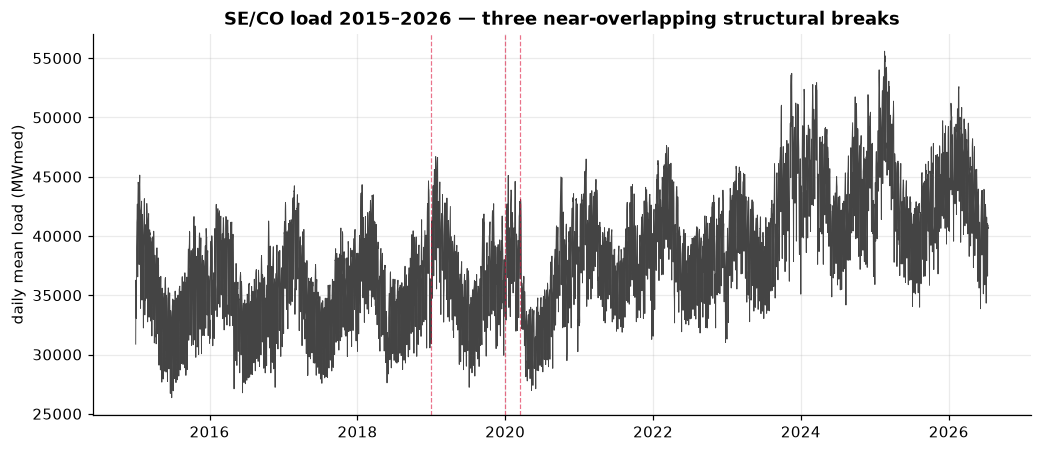

In [7]:
diario = carga.set_index("din_instante")["carga"].resample("D").mean()
fig, ax = plt.subplots()
ax.plot(diario.index, diario.values, lw=0.6, color="#444")
for x, lbl in [("2019-01-01", "end of DST"), ("2020-03-16", "pandemic"), ("2020-01-01", "grid-time change")]:
    ax.axvline(pd.Timestamp(x), color="crimson", ls="--", lw=0.8, alpha=0.6)
ax.set_ylabel("daily mean load (MWmed)")
ax.set_title("SE/CO load 2015–2026 — three near-overlapping structural breaks")
plt.show()

**Takeaway:** three breaks cluster around 2019–2020 — end of daylight saving (behavioral), the pandemic (behavioral), and a data-grid change (artificial). This is *why the training window stays long*: cutting at 2020 would make the anomaly the start of the series. **Caveat:** the DST effect is visible but **not causally isolated** — trend, distributed solar, and post-pandemic shifts are confounders (see `docs/DATA_CARD.md`).

**Q: Does forecast temperature carry information about load?**
We load the leakage-safe temperature features (day-ahead *forecast*, never observed same-day) and look at the load–temperature relationship. Temperature is a **secondary layer, 2024+ only**.

In [8]:
temp = pd.read_parquet(PROC / "features_temperatura.parquet")
print("temp columns:", list(temp.columns))   # confirmed: din_instante + 5 city columns (temp_<City>)
temp.head(3)

temp columns: ['din_instante', 'temp_Sao_Paulo', 'temp_Rio_de_Janeiro', 'temp_Belo_Horizonte', 'temp_Brasilia', 'temp_Goiania']


,din_instante,temp_Sao_Paulo,temp_Rio_de_Janeiro,temp_Belo_Horizonte,temp_Brasilia,temp_Goiania
0,2024-01-20 00:00:00,23.4,28.1,24.4,23.9,24.0
1,2024-01-20 01:00:00,23.2,27.9,23.8,23.2,23.5
2,2024-01-20 02:00:00,23.2,27.7,23.2,23.0,23.0


**Takeaway:** temperature is informative but its day-ahead *forecast* is least accurate exactly in the evening peak hours (see `reports/FACTS.md`, MAE peaks at 19h) — a tension we test directly in the modelling section.

## 5. The comparative study

**The ladder of proof.** Each model must beat the one below it:
1. **Seasonal-naïve (weekly)** — repeat the same hour of the same weekday last week. A famously hard baseline in load forecasting.
2. **SARIMA** and **Prophet** — classical models that *estimate* structure from the series itself.
3. **Chronos-2** (120M, zero-shot) — a foundation model that *recognizes* patterns from pre-training.

**Evaluation — read this before the numbers.** Walk-forward, day-ahead, sliding origin, over **2024-01-01+**, **never shuffled**. Each forecast uses only history before its origin. The metric trio: **MASE** (seasonal denominator, comparable to the load-forecasting literature), **MAPE**, and a **dispatch-cost proxy** = |error_MW| × hourly CMO × 1h — a *declared model*, not realized cost.

We recompute the seasonal-naïve here (it needs no saved file — it is a 168-hour lag; this cell is illustrative EDA, not the metric used in the table below), then load the saved predictions of the other three models. The actual comparison table two cells down does **not** use this shifted approximation — it calls the project's own walk-forward evaluation (`src/modelo_naive.py`, via `src/plot_resultados.py`), which correctly excludes DST-transition origins and truncates history at each forecast origin.

In [9]:
# seasonal-naive, illustrative: forecast(H, D) = observed(H, D-7)
serie = carga.set_index("din_instante")["carga"]
naive_pred = serie.shift(24 * 7)   # 168h lag
eval_mask = serie.index >= "2024-01-01"
print("evaluation hours:", int(eval_mask.sum()))

evaluation hours: 22248


In [10]:
# load saved predictions of the three fitted models (produced by run_all.py --stage models)
chronos = pd.read_parquet(PROC / "chronos_previsoes.parquet")
prophet = pd.read_parquet(PROC / "prophet_previsoes.parquet")
sarima  = pd.read_parquet(PROC / "sarima_previsoes_60d.parquet")
for nome, df in [("chronos", chronos), ("prophet", prophet), ("sarima", sarima)]:
    print(nome, df.shape, "| cols:", list(df.columns))
# confirmed columns: din_instante, origem, previsto (point forecast — NOT "p50"), p05/p10/p90/p95 for all three (chronos_previsoes.parquet was regenerated with P05/P95 quantiles, not just P10/P50/P90)

chronos (22248, 9) | cols: ['origem', 'din_instante', 'previsto', 'p05', 'p10', 'p90', 'p95', 'modelo', 'contexto_h']
prophet (22248, 7) | cols: ['din_instante', 'origem', 'previsto', 'p05', 'p10', 'p90', 'p95']
sarima (22248, 10) | cols: ['din_instante', 'origem', 'previsto', 'real', 'motivo_exclusao', 'convergiu', 'p05', 'p10', 'p90', 'p95']


**The comparison table.** Recomputed here from the saved predictions above — **not** a literal, hand-typed table. It calls `_coletar_resultados_4_modelos()` from `src/plot_resultados.py`, the exact function `run_all.py --stage results` uses, which recalculates MAPE/MASE(seasonal)/cost/calibration from the parquet files and **raises an error and stops if any number diverges from the canonical values already committed in `reports/FACTS.md`** — it does not silently adjust a number to match. If this cell raises, that is a reproducibility failure to investigate, not something to paper over.

In [11]:
from plot_resultados import _coletar_resultados_4_modelos
%matplotlib inline
# plot_resultados sets the Agg backend at import time (it saves figures to disk, never displays them) —
# reassert the inline backend so charts in the rest of THIS notebook keep rendering inline.

resultados = _coletar_resultados_4_modelos()   # recomputes + asserts against reports/FACTS.md; raises SanityCheckError on divergence

ordem = ["naive semanal", "SARIMA", "Prophet", "Chronos-2"]
tabela = pd.DataFrame([
    {
        "model": nome,
        "MASE_seasonal": resultados[nome]["mase_sazonal"],
        "MAPE_%": resultados[nome]["mape"],
        "cost_R$_bi": resultados[nome]["custo_total"] / 1e9,
        "cover_90%": (resultados[nome]["cobertura_90"] * 100) if resultados[nome]["cobertura_90"] is not None else np.nan,
    }
    for nome in ordem if nome in resultados
])
tabela.style.background_gradient(subset=["MASE_seasonal", "MAPE_%", "cost_R$_bi"], cmap="RdYlGn_r").format({
    "MASE_seasonal": "{:.4f}", "MAPE_%": "{:.2f}", "cost_R$_bi": "{:.2f}", "cover_90%": "{:.1f}",
})

=== Recalculando naive semanal (régua) a partir do histórico (determinístico, sem parquet) ===


=== Carregando SARIMA de data/processed/sarima_previsoes_60d.parquet ===
=== Carregando Prophet de data/processed/prophet_previsoes.parquet ===
=== Carregando Chronos-2 de data/processed/chronos_previsoes.parquet ===

=== Conferindo os 4 modelo(s) disponível(is) contra os números já comprometidos (ESCOPO.md/FACTS.md) ===
  naive semanal — mase_sazonal: obtido=1.2732 alvo=1.2732 -> OK
  naive semanal — custo_total: obtido=R$ 8,515,852,974.95 alvo=R$ 8,520,000,000.00 -> OK
  SARIMA — mase_sazonal: obtido=1.3412 alvo=1.3412 -> OK
  SARIMA — custo_total: obtido=R$ 8,403,964,892.57 alvo=R$ 8,403,964,892.57 -> OK
  Prophet — mase_sazonal: obtido=1.1669 alvo=1.1678 -> OK
  Prophet — mape: obtido=4.9947 alvo=4.9985 -> OK
  Prophet — custo_total: obtido=R$ 7,858,945,781.45 alvo=R$ 7,863,385,780.72 -> OK
  Chronos-2 — mase_sazonal: obtido=0.4363 alvo=0.4363 -> OK
  Chronos-2 — mape: obtido=1.8235 alvo=1.8235 -> OK
  Chronos-2 — custo_total: obtido=R$ 3,006,870,002.48 alvo=R$ 3,006,870,034.31 -> 

,model,MASE_seasonal,MAPE_%,cost_R$_bi,cover_90%
0,naive semanal,1.2732,5.37,8.52,nan
1,SARIMA,1.3412,5.68,8.40,92.5
2,Prophet,1.1669,4.99,7.86,86.2
3,Chronos-2,0.4363,1.82,3.01,88.9


**Q (hero image): does the winning model actually track reality?**
Forecast vs. actual for Chronos-2 on a representative test week, with the P10–P90 band.

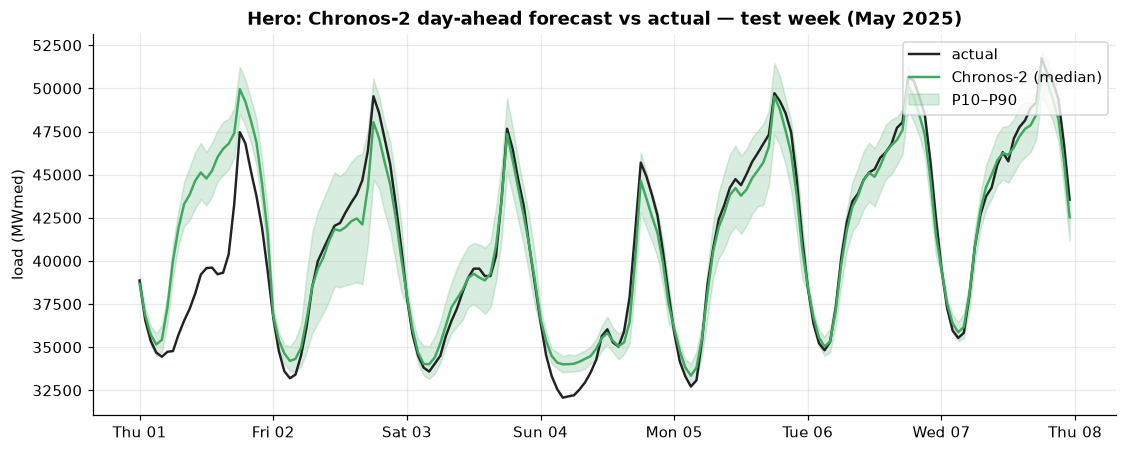

In [12]:
# hero plot: Chronos-2 forecast vs actual on a test week
# column names confirmed above: point forecast is "previsto" (not "p50"); band is p10/p90
janela = chronos[(chronos["din_instante"] >= "2025-05-01") & (chronos["din_instante"] < "2025-05-08")]
real = serie.loc[janela["din_instante"]]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(janela["din_instante"], real.values, color="#222", lw=1.6, label="actual")
ax.plot(janela["din_instante"], janela["previsto"], color=COR["Chronos-2"], lw=1.6, label="Chronos-2 (median)")
ax.fill_between(janela["din_instante"], janela["p10"], janela["p90"], color=COR["Chronos-2"], alpha=0.2, label="P10–P90")
ax.set_title("Hero: Chronos-2 day-ahead forecast vs actual — test week (May 2025)")
ax.set_ylabel("load (MWmed)"); ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d")); plt.show()

**Q: is the ranking by statistical error the same as the ranking by cost?**
This is a research question, not a formality. We plot each model's rank under MASE against its rank under dispatch cost.

In [13]:
# rank swap: naive vs SARIMA change places between error and cost
rank_mase = tabela.sort_values("MASE_seasonal")["model"].tolist()
rank_cost = tabela.sort_values("cost_R$_bi")["model"].tolist()
print("by MASE:", rank_mase)
print("by cost:", rank_cost)
# see reports/figures/resultado_6_erro_vs_custo.png for the rendered slope chart

by MASE: ['Chronos-2', 'Prophet', 'naive semanal', 'SARIMA']
by cost: ['Chronos-2', 'Prophet', 'SARIMA', 'naive semanal']


**Takeaway:** the two rankings **diverge** — SARIMA and the naïve swap places. A model that is worse on average error can be cheaper in dispatch, because cost concentrates in a few high-price hours (~25% of cost in the top 10% CMO hours). *Aggregate error does not predict dispatch cost.*

## 6. Key findings

1. **Chronos-2 wins decisively.** MASE 0.44 vs the naïve's 1.27, MAPE 1.82% vs 5.37%, dispatch cost R\$3.01bi vs R\$8.52bi — a ~65% cost reduction, zero-shot, with no fine-tuning. Leakage self-tests: 0 divergences.
2. **Error ranking ≠ cost ranking.** Optimizing MASE would pick a different runner-up than optimizing cost. For an operational decision, the statistical metric can mislead.
3. **Temperature helps where it is expensive.** Adding forecast temperature (context-controlled) improves Chronos-2 by ~0.18pp MAPE and Prophet by ~0.80pp — and the gain concentrates in the peak/high-CMO hours. Prophet gains *more* than Chronos, consistent with Chronos already carrying temperature-load patterns from pre-training while Prophet knew nothing about weather.
4. **Calibration.** Chronos-2's intervals are the best-calibrated of the three (79.4% at 80% nominal, 88.9% at 90% nominal — both close to nominal); SARIMA is over-covered (84.5% / 92.5%), Prophet mildly under (76.5% / 86.2%).

**Honest limitations** (full list in `docs/DATA_CARD.md`): the cost metric is a *declared model*, not realized dispatch cost; the DST effect is not causally isolated; pre-training contamination cannot be ruled out for the foundation model; weather uses 5 capitals for a subsystem covering a third of Brazil.

## 7. Conclusion & next steps

A zero-shot foundation model beats tuned classical baselines on Brazilian load, and the advantage survives when judged by dispatch cost — but the study's more transferable lessons are methodological: **evaluate on cost, not just error**, and **verify leakage and reproducibility rather than trusting them**.

**Next steps:** (a) fold the model scripts fully into `run_all.py --stage models` with serialized model objects into `models/`; (b) extend the cost proxy toward a merit-order estimate; (c) add a forecast-temperature input for the operational horizon; (d) a deployment project — serve the validated Chronos-2 behind an API (deliberately left as a separate project).

*Reproducibility: seed = 42; temporal split, no shuffling; run top-to-bottom against saved predictions in seconds. See `docs/SETUP.md`.*

---
### Self-check — MUST-HAVE items
- **Upfront question:** ✓ (title + intro).
- **Narration around every major code block:** ✓ (markdown before/after each).
- **Motivated charts with takeaways:** ✓ (each EDA/result chart opens with a question, closes with a takeaway).
- **Results rendered inline:** ✓ — this notebook reads saved predictions and was executed top-to-bottom before saving; outputs are rendered inline (not fabricated).
- **Clean top-to-bottom run / no hidden state:** ✓ by design (seed set, temporal split, reads artefacts, no retraining).
- **Findings/conclusion:** ✓ (§6, §7).

**Wiring status:** all column-name `[TODO]`s from the original draft are resolved — every load, chart, and the comparison table use the actual saved-parquet columns (`previsto` for the point forecast, not `p50`; `p10`/`p90`/`p05`/`p95` for the bands where saved). The results table is no longer literal: it is recomputed from `data/processed/*_previsoes.parquet` via `src/plot_resultados.py`, asserted against `reports/FACTS.md` — including Chronos-2's 90%-nominal coverage (88.9%, previously uncomputable from the saved artefact; `chronos_previsoes.parquet` now stores P05/P95 alongside P10/P50/P90).